# AndinaLog 03B — Auditoría, Integración y EDA v3

**Grupo 06 · Operaciones y Planificación de Datos**

Este notebook parte de las seis capas Silver disponibles y construye las tres evidencias del subcaso 03B:

1. excursiones térmicas por viaje;
2. vencimiento, merma, rotación y costos;
3. lecturas preparadas para la alerta térmica de los próximos 60 minutos.

El flujo sigue los principios trabajados en S3–S10: explorar antes de modelar, declarar la granularidad, agregar antes de unir hechos, medir cobertura, conservar banderas y evitar información futura.


## 0. Configuración y carga reproducible

Las fechas sin zona explícita se interpretan como hora de Bolivia. Los seis archivos Silver se leen sin modificar. Las salidas se escriben en una carpeta separada.


In [1]:
from pathlib import Path
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid', context='notebook')
SEMILLA = 42

def encontrar_raiz():
    raiz_env = os.environ.get('ANDINALOG_ROOT')
    if raiz_env:
        p=Path(raiz_env)
        if (p/'proyecto-integrador').is_dir(): return p
    if 'google.colab' in sys.modules:
        from google.colab import drive
        drive.mount('/content/drive')
        for p in [Path('/content/drive/MyDrive/GIAD'), Path('/content/drive/MyDrive/practicasNotebookColab')]:
            if (p/'proyecto-integrador').is_dir(): return p
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p/'proyecto-integrador').is_dir(): return p
    raise FileNotFoundError('No se encontró la raíz de practicasNotebookColab')

RAIZ=encontrar_raiz()
BASE=RAIZ/'proyecto-integrador'/'02_tratamiento'
SALIDA=Path(os.environ.get('ANDINALOG_EDA_OUTPUT_DIR', RAIZ/'proyecto-integrador'/'03_EDA'/'salidas_v3'))
SALIDA.mkdir(parents=True, exist_ok=True)

RUTAS={
 'iot':BASE/'andinalog_iot_telemetry/salidas/andinalog_iot_telemetry_didactico_v2_silver.csv',
 'productos':BASE/'andinalog_productos/salidas/andinalog_productos_didactico_v2_silver.csv',
 'flota':BASE/'andinalog_flota/salidas/andinalog_flota_didactico_v2_silver.csv',
 'inventario':BASE/'andinalog_inventory_tracking/salidas/andinalog_inventory_tracking_didactico_v2_silver.csv',
 'wms':BASE/'andinalog_wms_orders/salidas/andinalog_wms_orders_didactico_v2_silver.csv',
 'warehouse':BASE/'andinalog_warehouse_costs/salidas/andinalog_warehouse_costs_didactico_v2_silver.csv',
}
for nombre,ruta in RUTAS.items():
    if not ruta.is_file(): raise FileNotFoundError(f'Falta {nombre}: {ruta}')
tablas={n:pd.read_csv(p,encoding='utf-8-sig') for n,p in RUTAS.items()}
iot,productos,flota,inv,wms,warehouse=[tablas[n] for n in ['iot','productos','flota','inventario','wms','warehouse']]
print('Raíz:',RAIZ)
print('Salidas:',SALIDA)
print({n:len(t) for n,t in tablas.items()})


Raíz: C:\Users\remrodri\Github\practicasNotebookColab
Salidas: C:\Users\remrodri\Documents\Codex\2026-09-21\referenced-chatgpt-conversation-this-is-an-2\outputs\eda_integrado_v3\salidas
{'iot': 28677, 'productos': 60, 'flota': 30, 'inventario': 5980, 'wms': 7468, 'warehouse': 5}


## 1. Auditoría de entrada de los seis Silver

Esta etapa verifica aptitud para integrar. No repite las reglas detalladas del diagnóstico. Las claves maestras deben ser únicas y ninguna salida Silver puede conservar filas en cuarentena final.


In [2]:
contratos={
 'iot':('fila_bronze',True),
 'productos':('producto_id_tratado',True),
 'flota':('camion_id_tratado',True),
 'inventario':('movimiento_id',True),
 'wms':('order_id_tratado',True),
 'warehouse':(['centro_distribucion_tratado','periodo_mes_tratado'],True),
}
filas=[]
for nombre,df in tablas.items():
    clave,esperada=contratos[nombre]
    cols=[clave] if isinstance(clave,str) else clave
    duplicados=int(df.duplicated(cols).sum())
    qfinal=int(df['en_cuarentena_final'].fillna(False).astype(bool).sum()) if 'en_cuarentena_final' in df else 0
    filas.append({
        'silver':nombre,'filas':len(df),'columnas':len(df.columns),'clave':' + '.join(cols),
        'duplicados_clave':duplicados,'cuarentena_final':qfinal,
        'nulos_clave':int(df[cols].isna().any(axis=1).sum()),
        'apto_integrar':duplicados==0 and qfinal==0 and not df[cols].isna().any(axis=1).any(),
    })
auditoria=pd.DataFrame(filas)
display(auditoria)
assert auditoria['apto_integrar'].all()
assert productos['producto_id_tratado'].is_unique
assert flota['camion_id_tratado'].is_unique
assert wms['order_id_tratado'].is_unique
assert not warehouse.duplicated(['centro_distribucion_tratado','periodo_mes_tratado']).any()
assert iot['zona_horaria_origen'].eq('America/La_Paz').all()
auditoria.to_csv(SALIDA/'andinalog_03b_auditoria_silver.csv',index=False,encoding='utf-8-sig')
print('Auditoría superada: los seis Silver son aptos para el EDA integrado.')


,silver,filas,columnas,clave,duplicados_clave,cuarentena_final,nulos_clave,apto_integrar
0,iot,28677,55,fila_bronze,0,0,0,True
1,productos,60,41,producto_id_tratado,0,0,0,True
2,flota,30,25,camion_id_tratado,0,0,0,True
3,inventario,5980,58,movimiento_id,0,0,0,True
4,wms,7468,68,order_id_tratado,0,0,0,True
5,warehouse,5,28,centro_distribucion_tratado + periodo_mes_tratado,0,0,0,True


Auditoría superada: los seis Silver son aptos para el EDA integrado.


## 2. EDA básico por fuente

Se resumen únicamente las variables necesarias para comprender las fuentes y preparar las evidencias. Los valores atípicos plausibles se describen; no se eliminan automáticamente.


IoT — lecturas por viaje


,lecturas_por_viaje
count,1200.000000
mean,23.897500
std,0.314234
min,22.000000
25%,24.000000
50%,24.000000
75%,24.000000
max,24.000000


Productos — categorías


,categoria,productos
0,Seco,30
1,Fresco,20
2,Congelado,10


Flota — tipos y capacidad


...

,centro_distribucion_tratado,ordenes,otif_pct
0,Cochabamba,1429,79.08
1,La Paz,1477,80.97
2,Oruro,1485,78.86
3,Santa Cruz,1508,79.24
4,Tarija,1569,79.92


Inventario — vencimientos imputados


,vencimiento_imputado,lotes
0,False,5962
1,True,18


Warehouse Costs — centro y periodo


,centro_distribucion_tratado,periodo_mes_tratado,rotacion_stock_dias_tratado,perdida_mermas_bob_tratado,costo_almacenamiento_mensual_bob_tratado
0,Cochabamba,2026-08,17.23,483014.65,140000
1,La Paz,2026-08,16.94,453976.70,180000
2,Oruro,2026-08,17.21,506458.32,95000
3,Santa Cruz,2026-08,17.73,484945.21,220000
4,Tarija,2026-08,16.88,467199.52,110000


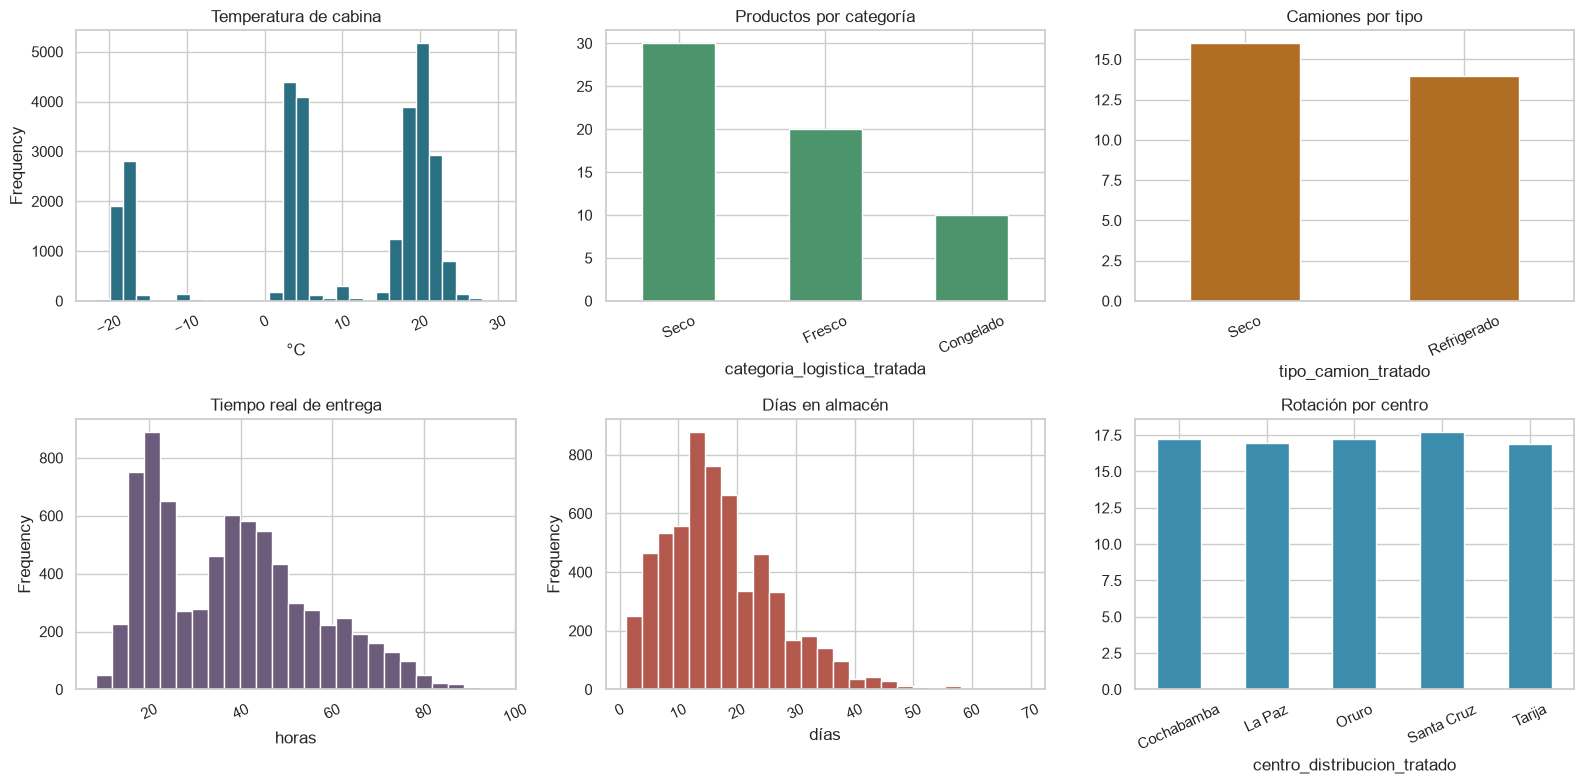

In [3]:
print('IoT — lecturas por viaje')
display(iot.groupby('viaje_id').size().describe().to_frame('lecturas_por_viaje'))
print('Productos — categorías')
display(productos['categoria_logistica_tratada'].value_counts().rename_axis('categoria').reset_index(name='productos'))
print('Flota — tipos y capacidad')
display(flota.groupby('tipo_camion_tratado').agg(camiones=('camion_id_tratado','size'),capacidad_mediana_kg=('capacidad_kg_tratada','median')).reset_index())
print('WMS — OTIF observado')
display(wms.groupby('centro_distribucion_tratado').agg(ordenes=('order_id_tratado','size'),otif_pct=('otif_tratado',lambda s:100*pd.to_numeric(s).mean())).round(2).reset_index())
print('Inventario — vencimientos imputados')
display(inv['vencimiento_imputado'].value_counts(dropna=False).rename_axis('vencimiento_imputado').reset_index(name='lotes'))
print('Warehouse Costs — centro y periodo')
display(warehouse[['centro_distribucion_tratado','periodo_mes_tratado','rotacion_stock_dias_tratado','perdida_mermas_bob_tratado','costo_almacenamiento_mensual_bob_tratado']])

fig,axes=plt.subplots(2,3,figsize=(16,8))
pd.to_numeric(iot['temperatura_cabina_c_tratada']).plot.hist(bins=30,ax=axes[0,0],color='#2B6F82',title='Temperatura de cabina')
axes[0,0].set_xlabel('°C')
productos['categoria_logistica_tratada'].value_counts().plot.bar(ax=axes[0,1],color='#4C956C',title='Productos por categoría')
flota['tipo_camion_tratado'].value_counts().plot.bar(ax=axes[0,2],color='#AF6E24',title='Camiones por tipo')
pd.to_numeric(wms['tiempo_entrega_real_hrs_tratado']).plot.hist(bins=25,ax=axes[1,0],color='#6C5B7B',title='Tiempo real de entrega')
axes[1,0].set_xlabel('horas')
pd.to_numeric(inv['dias_en_almacen_tratada']).plot.hist(bins=25,ax=axes[1,1],color='#B3584C',title='Días en almacén')
axes[1,1].set_xlabel('días')
warehouse.set_index('centro_distribucion_tratado')['rotacion_stock_dias_tratado'].astype(float).plot.bar(ax=axes[1,2],color='#3C8DAD',title='Rotación por centro')
for ax in axes.flat: ax.tick_params(axis='x',rotation=25)
plt.tight_layout(); plt.show()


## 3. Contrato y auditoría de joins

La población principal se conserva con uniones `left`. Productos, Flota y WMS son dimensiones únicas en sus claves tratadas. Se comprueba cobertura y ausencia de multiplicación.


In [4]:
def registrar_join(nombre,origen,resultado,indicador,clave,cardinalidad):
    match=int(resultado[indicador].eq('both').sum())
    return {'join':nombre,'clave':clave,'cardinalidad':cardinalidad,'filas_antes':len(origen),
            'filas_despues':len(resultado),'filas_match':match,'sin_match':len(resultado)-match,
            'cobertura_pct':100*match/len(resultado),'multiplico_filas':len(resultado)!=len(origen)}

pcols=['producto_id_tratado','categoria_logistica_tratada','temperatura_conservacion_requerida_c_tratada','tolerancia_temperatura_c_tratada','categoria_imputada','temperatura_imputada','apto_umbral_termico_observado']
fcols=['camion_id_tratado','tipo_camion_tratado','centro_distribucion_base_tratado','capacidad_kg_tratada']
wcols=['order_id_tratado','centro_distribucion_tratado','cantidad_solicitada_tratado','tiempo_entrega_prometido_hrs_tratado','apta_modelo_predespacho']

tel1=iot.merge(productos[pcols],left_on='producto_id',right_on='producto_id_tratado',how='left',validate='many_to_one',indicator='_join_producto')
tel2=tel1.merge(flota[fcols],on='camion_id_tratado',how='left',validate='many_to_one',indicator='_join_flota')
tel3=tel2.merge(wms[wcols],left_on='order_id',right_on='order_id_tratado',how='left',validate='many_to_one',indicator='_join_wms')

inv1=inv.merge(productos[['producto_id_tratado','categoria_logistica_tratada','categoria_imputada']],on='producto_id_tratado',how='left',validate='many_to_one',indicator='_join_producto_inv')

reporte_joins=pd.DataFrame([
 registrar_join('IoT → Productos',iot,tel1,'_join_producto','producto_id','muchos a uno'),
 registrar_join('IoT → Flota',tel1,tel2,'_join_flota','camion_id','muchos a uno'),
 registrar_join('IoT → WMS Orders',tel2,tel3,'_join_wms','order_id','muchos a uno'),
 registrar_join('Inventario → Productos',inv,inv1,'_join_producto_inv','producto_id','muchos a uno'),
])
display(reporte_joins.round(2))
assert not reporte_joins['multiplico_filas'].any()
assert reporte_joins.loc[reporte_joins['join'].isin(['IoT → Productos','IoT → Flota','Inventario → Productos']),'cobertura_pct'].eq(100).all()
reporte_joins.to_csv(SALIDA/'andinalog_03b_reporte_joins.csv',index=False,encoding='utf-8-sig')


,join,clave,cardinalidad,filas_antes,filas_despues,filas_match,sin_match,cobertura_pct,multiplico_filas
0,IoT → Productos,producto_id,muchos a uno,28677,28677,28677,0,100.00,False
1,IoT → Flota,camion_id,muchos a uno,28677,28677,28677,0,100.00,False
2,IoT → WMS Orders,order_id,muchos a uno,28677,28677,28582,95,99.67,False
3,Inventario → Productos,producto_id,muchos a uno,5980,5980,5980,0,100.00,False


## 4. Evidencia 1 — excursiones térmicas por viaje

**Granularidad:** una fila por viaje. IoT se agrega antes de analizar Productos y Flota. El porcentaje utiliza viajes como denominador.


,categoria_logistica,tipo_camion,viajes,viajes_con_desviacion,temperatura_promedio_c,pct_viajes_con_desviacion
0,Congelado,Refrigerado,203,76,-17.73,37.44
1,Congelado,Seco,9,8,-17.16,88.89
2,Fresco,Refrigerado,313,120,4.24,38.34
3,Fresco,Seco,8,7,5.14,87.50
4,Seco,Refrigerado,291,55,20.08,18.90
5,Seco,Seco,276,45,20.06,16.30


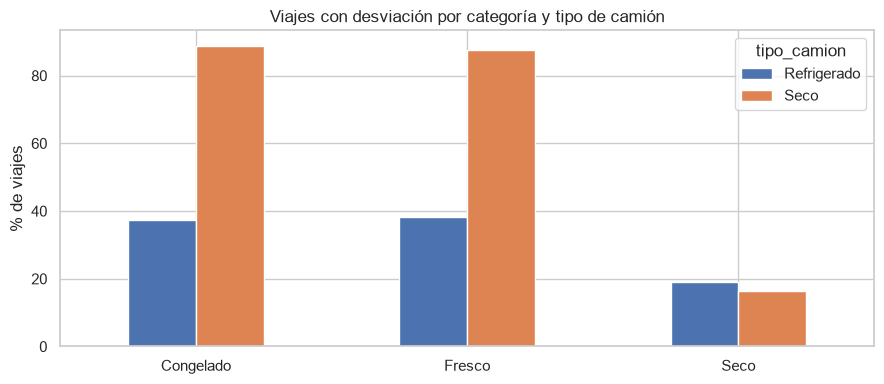

In [5]:
tel=tel3.copy()
tel['timestamp_bolivia']=pd.to_datetime(tel['timestamp_bolivia_tratado'],errors='coerce')
tel['temp_c']=pd.to_numeric(tel['temperatura_cabina_c_tratada'],errors='coerce')
tel['humedad_pct']=pd.to_numeric(tel['humedad_cabina_pct_tratada'],errors='coerce')
tel['objetivo_c']=pd.to_numeric(tel['temperatura_conservacion_requerida_c_tratada'],errors='coerce')
tel['tolerancia_c']=pd.to_numeric(tel['tolerancia_temperatura_c_tratada'],errors='coerce')
tel['desvio_respecto_umbral_c']=(tel['temp_c']-tel['objetivo_c']).abs()-tel['tolerancia_c']
tel['excursion_calculada']=tel['desvio_respecto_umbral_c'].gt(0)
tel['flag_actual']=pd.to_numeric(tel['desviacion_termica_flag'],errors='coerce').eq(1)
tel['flag_60min']=pd.to_numeric(tel['desviacion_proximos_60min_flag'],errors='coerce')
tel['temp_observada']=~tel['temperatura_imputada_x'].fillna(False).astype(bool) if 'temperatura_imputada_x' in tel else ~tel['temperatura_imputada'].fillna(False).astype(bool)
tel['umbral_observado']=tel['apto_umbral_termico_observado'].fillna(False).astype(bool)
tel['lectura_termica_observada']=tel['temp_observada'] & tel['umbral_observado'] & tel['temp_c'].notna()
tel['temp_c_observada']=tel['temp_c'].where(tel['lectura_termica_observada'])
tel['excursion_observada']=tel['excursion_calculada'] & tel['lectura_termica_observada']
assert (tel.loc[tel['lectura_termica_observada'],'excursion_calculada']==tel.loc[tel['lectura_termica_observada'],'flag_actual']).all()

viajes=tel.groupby(['viaje_id','order_id','camion_id_tratado','producto_id'],as_index=False).agg(
    inicio_viaje=('timestamp_bolivia','min'),fin_viaje=('timestamp_bolivia','max'),
    n_lecturas=('fila_bronze','size'),n_lecturas_observadas=('lectura_termica_observada','sum'),
    temperatura_promedio_c=('temp_c_observada','mean'),temperatura_maxima_c=('temp_c_observada','max'),
    n_desviaciones=('excursion_observada','sum'),categoria_logistica=('categoria_logistica_tratada','first'),
    tipo_camion=('tipo_camion_tratado','first'),centro_distribucion=('centro_distribucion_tratado','first'))
viajes['tuvo_desviacion']=viajes['n_desviaciones'].gt(0)
viajes['apto_kpi_termico_observado']=viajes['n_lecturas_observadas'].gt(0)
assert viajes['viaje_id'].is_unique
resumen_viajes=viajes.loc[viajes['apto_kpi_termico_observado']].groupby(['categoria_logistica','tipo_camion'],as_index=False).agg(
    viajes=('viaje_id','size'),viajes_con_desviacion=('tuvo_desviacion','sum'),
    temperatura_promedio_c=('temperatura_promedio_c','mean'),
    pct_viajes_con_desviacion=('tuvo_desviacion',lambda s:100*s.mean()))
display(resumen_viajes.round(2))
viajes.to_csv(SALIDA/'andinalog_03b_evidencia_1_viajes.csv',index=False,encoding='utf-8-sig')

ax=resumen_viajes.pivot(index='categoria_logistica',columns='tipo_camion',values='pct_viajes_con_desviacion').plot.bar(figsize=(9,4))
ax.set_title('Viajes con desviación por categoría y tipo de camión'); ax.set_ylabel('% de viajes'); ax.set_xlabel(''); plt.xticks(rotation=0); plt.tight_layout(); plt.show()


## 5. Evidencia 2 — vencimiento, merma, rotación y costos

**Granularidades:** una fila por lote/movimiento y una fila por centro-periodo. La fecha de salida vacía significa que el lote continúa en almacén. Los vencimientos imputados conservan su bandera.


In [6]:
lotes=inv1.copy()
lotes['fecha_ingreso_dt']=pd.to_datetime(lotes['fecha_ingreso_tratada'],errors='coerce')
lotes['fecha_salida_dt']=pd.to_datetime(lotes['fecha_salida_tratada'],errors='coerce')
lotes['fecha_vencimiento_dt']=pd.to_datetime(lotes['fecha_vencimiento_tratada'],errors='coerce')
lotes['aun_en_almacen']=lotes['fecha_salida_dt'].isna()
fecha_referencia=pd.Timestamp('2026-08-31')
lotes['dias_para_vencer']=np.where(lotes['aun_en_almacen'],(lotes['fecha_vencimiento_dt']-fecha_referencia).dt.days,(lotes['fecha_vencimiento_dt']-lotes['fecha_salida_dt']).dt.days)
lotes['cantidad_merma_num']=pd.to_numeric(lotes['cantidad_merma_tratada'],errors='coerce')
lotes['costo_unitario_num']=pd.to_numeric(lotes['costo_unitario_bob_tratada'],errors='coerce')
lotes['valor_merma_estimado_bob']=lotes['cantidad_merma_num']*lotes['costo_unitario_num']
lotes['riesgo_vencimiento']=pd.cut(lotes['dias_para_vencer'],[-np.inf,-1,30,90,np.inf],labels=['VENCIDO','ALTO','MEDIO','BAJO'])
lotes['periodo_mes_analitico']=lotes['fecha_salida_dt'].fillna(lotes['fecha_ingreso_dt']).dt.to_period('M').astype(str)

resumen_lotes=lotes.groupby(['categoria_logistica_tratada','riesgo_vencimiento'],observed=True,as_index=False).agg(lotes=('lote_id','size'),merma_unidades=('cantidad_merma_num','sum'),valor_merma_estimado_bob=('valor_merma_estimado_bob','sum'))
display(resumen_lotes.round(2))
lotes.to_csv(SALIDA/'andinalog_03b_evidencia_2_lotes.csv',index=False,encoding='utf-8-sig')

centros_inv=lotes.groupby(['centro_distribucion','periodo_mes_analitico'],as_index=False).agg(
    movimientos=('movimiento_id','size'),lotes=('lote_id','nunique'),merma_unidades=('cantidad_merma_num','sum'),
    valor_merma_estimado_bob=('valor_merma_estimado_bob','sum'),dias_promedio_almacen=('dias_en_almacen_tratada',lambda s:pd.to_numeric(s).mean()))
centros=warehouse.merge(centros_inv,left_on=['centro_distribucion_tratado','periodo_mes_tratado'],right_on=['centro_distribucion','periodo_mes_analitico'],how='left',validate='one_to_one',indicator='_join_inventario_mes')
centros['cobertura_inventario_mes']=centros['_join_inventario_mes'].eq('both')
display(centros[['centro_distribucion_tratado','periodo_mes_tratado','rotacion_stock_dias_tratado','perdida_mermas_bob_tratado','valor_merma_estimado_bob','costo_almacenamiento_mensual_bob_tratado','cobertura_inventario_mes']].round(2))
centros.to_csv(SALIDA/'andinalog_03b_evidencia_2_centros.csv',index=False,encoding='utf-8-sig')


,categoria_logistica_tratada,riesgo_vencimiento,lotes,merma_unidades,valor_merma_estimado_bob
0,Congelado,BAJO,1046,7676,370511.77
1,Fresco,VENCIDO,468,12050,552783.54
2,Fresco,ALTO,1511,22128,970936.23
3,Seco,BAJO,2955,11454,496605.82


,centro_distribucion_tratado,periodo_mes_tratado,rotacion_stock_dias_tratado,perdida_mermas_bob_tratado,valor_merma_estimado_bob,costo_almacenamiento_mensual_bob_tratado,cobertura_inventario_mes
0,Cochabamba,2026-08,17.23,483014.65,125869.42,140000,True
1,La Paz,2026-08,16.94,453976.70,128817.06,180000,True
2,Oruro,2026-08,17.21,506458.32,119212.75,95000,True
3,Santa Cruz,2026-08,17.73,484945.21,125119.65,220000,True
4,Tarija,2026-08,16.88,467199.52,118528.79,110000,True


## 6. Evidencia 3 — lecturas para alerta térmica a 60 minutos

**Granularidad:** una lectura IoT. Las variables temporales se calculan después de ordenar y siempre dentro de `viaje_id`. El objetivo de clasificación recibido se conserva. El objetivo continuo se calcula exclusivamente con lecturas posteriores del mismo viaje, en el intervalo `(t, t+60 min]`.


,metrica,valor
0,lecturas,28677.00
1,viajes,1200.00
2,aptas_clasificacion,28557.00
3,positivos_clasificacion,1322.00
4,prevalencia_clasificacion_pct,4.63
5,aptas_regresion,27477.00


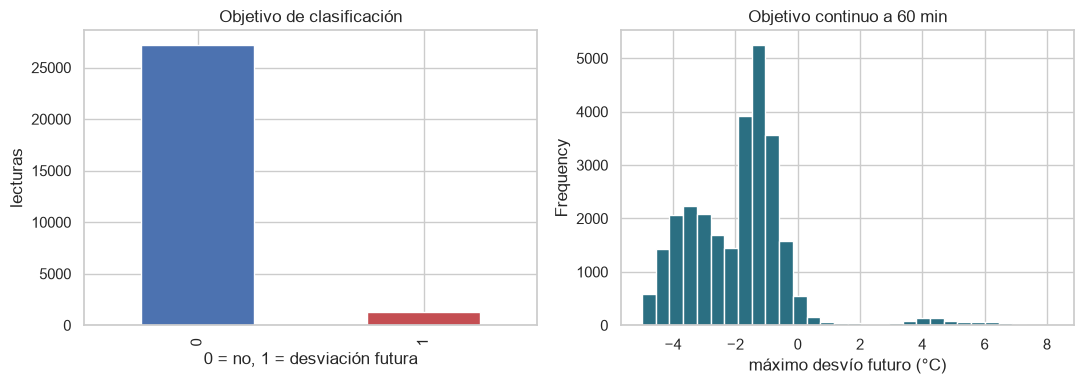

In [7]:
lecturas=tel.sort_values(['viaje_id','timestamp_bolivia','fila_bronze'],kind='stable').copy()
g=lecturas.groupby('viaje_id',sort=False)
lecturas['temp_lag1_c']=g['temp_c'].shift(1)
lecturas['temp_lag2_c']=g['temp_c'].shift(2)
lecturas['timestamp_lag1']=g['timestamp_bolivia'].shift(1)
lecturas['delta_min']=(lecturas['timestamp_bolivia']-lecturas['timestamp_lag1']).dt.total_seconds()/60
lecturas['cambio_temp_c']=lecturas['temp_c']-lecturas['temp_lag1_c']
lecturas['pendiente_c_por_min']=lecturas['cambio_temp_c']/lecturas['delta_min']
lecturas['minutos_desde_inicio']=(lecturas['timestamp_bolivia']-g['timestamp_bolivia'].transform('min')).dt.total_seconds()/60
lecturas['temp_media_historica_3']=g['temp_c'].transform(lambda s:s.rolling(3,min_periods=1).mean())
lecturas['temp_max_historica_3']=g['temp_c'].transform(lambda s:s.rolling(3,min_periods=1).max())
lecturas['clasificacion_objetivo_60min']=pd.to_numeric(lecturas['desviacion_proximos_60min_flag'],errors='coerce')

lecturas['max_desvio_termico_proximos_60min_c']=np.nan
lecturas['n_lecturas_futuras_60min']=0
for viaje_id,idx in lecturas.groupby('viaje_id',sort=False).groups.items():
    pos=list(idx); tiempos=lecturas.loc[pos,'timestamp_bolivia']; desv=lecturas.loc[pos,'desvio_respecto_umbral_c']
    for j,ix in enumerate(pos):
        mascara=(tiempos>tiempos.loc[ix]) & (tiempos<=tiempos.loc[ix]+pd.Timedelta(minutes=60))
        futuros=desv.loc[mascara]
        lecturas.at[ix,'n_lecturas_futuras_60min']=int(futuros.notna().sum())
        if futuros.notna().any(): lecturas.at[ix,'max_desvio_termico_proximos_60min_c']=float(futuros.max())

lecturas['apta_regresion_60min']=lecturas['max_desvio_termico_proximos_60min_c'].notna() & lecturas['temp_c'].notna() & lecturas['objetivo_c'].notna()
lecturas['apta_clasificacion_60min']=lecturas['apta_objetivo_60min'].fillna(False).astype(bool) & lecturas['clasificacion_objetivo_60min'].notna()
columnas_salida=['fila_bronze','viaje_id','order_id','camion_id_tratado','producto_id','timestamp_bolivia','temp_c','humedad_pct','objetivo_c','tolerancia_c','desvio_respecto_umbral_c','temp_lag1_c','temp_lag2_c','cambio_temp_c','pendiente_c_por_min','temp_media_historica_3','temp_max_historica_3','minutos_desde_inicio','categoria_logistica_tratada','tipo_camion_tratado','capacidad_kg_tratada','centro_distribucion_tratado','cantidad_solicitada_tratado','tiempo_entrega_prometido_hrs_tratado','temperatura_imputada_x','humedad_imputada','clasificacion_objetivo_60min','max_desvio_termico_proximos_60min_c','n_lecturas_futuras_60min','apta_clasificacion_60min','apta_regresion_60min']
columnas_salida=[c for c in columnas_salida if c in lecturas]
evidencia3=lecturas[columnas_salida].copy()
evidencia3.to_csv(SALIDA/'andinalog_03b_evidencia_3_lecturas.csv',index=False,encoding='utf-8-sig')

resumen_objetivos=pd.DataFrame({
 'metrica':['lecturas','viajes','aptas_clasificacion','positivos_clasificacion','prevalencia_clasificacion_pct','aptas_regresion'],
 'valor':[len(evidencia3),evidencia3['viaje_id'].nunique(),int(evidencia3['apta_clasificacion_60min'].sum()),int(evidencia3.loc[evidencia3['apta_clasificacion_60min'],'clasificacion_objetivo_60min'].sum()),100*evidencia3.loc[evidencia3['apta_clasificacion_60min'],'clasificacion_objetivo_60min'].mean(),int(evidencia3['apta_regresion_60min'].sum())]
})
display(resumen_objetivos.round(2))

fig,axes=plt.subplots(1,2,figsize=(11,4))
evidencia3.loc[evidencia3['apta_clasificacion_60min'],'clasificacion_objetivo_60min'].value_counts().sort_index().plot.bar(ax=axes[0],color=['#4C72B0','#C44E52'],title='Objetivo de clasificación')
axes[0].set_xlabel('0 = no, 1 = desviación futura'); axes[0].set_ylabel('lecturas')
evidencia3.loc[evidencia3['apta_regresion_60min'],'max_desvio_termico_proximos_60min_c'].plot.hist(bins=30,ax=axes[1],color='#2B6F82',title='Objetivo continuo a 60 min')
axes[1].set_xlabel('máximo desvío futuro (°C)')
plt.tight_layout(); plt.show()


## 7. Validaciones finales y lectura del EDA

Las pruebas verifican conservación de granularidad, unicidad de las evidencias, cobertura de maestros y ausencia de información de otros viajes en las variables temporales. Este notebook todavía no entrena modelos.


In [8]:
assert len(tel)==len(iot)
assert viajes['viaje_id'].is_unique
assert lotes['movimiento_id'].is_unique
assert len(centros)==len(warehouse)
assert len(evidencia3)==len(iot)
assert evidencia3['fila_bronze'].is_unique
assert (evidencia3['n_lecturas_futuras_60min']>=0).all()
assert evidencia3.loc[evidencia3['apta_regresion_60min'],'max_desvio_termico_proximos_60min_c'].notna().all()

archivos=['andinalog_03b_auditoria_silver.csv','andinalog_03b_reporte_joins.csv','andinalog_03b_evidencia_1_viajes.csv','andinalog_03b_evidencia_2_lotes.csv','andinalog_03b_evidencia_2_centros.csv','andinalog_03b_evidencia_3_lecturas.csv']
for a in archivos: assert (SALIDA/a).is_file(),a
print('✓ Seis Silver auditados')
print('✓ Joins sin multiplicación')
print('✓ Tres evidencias construidas')
print('✓ Objetivos de clasificación y regresión disponibles')


✓ Seis Silver auditados
✓ Joins sin multiplicación
✓ Tres evidencias construidas
✓ Objetivos de clasificación y regresión disponibles


## 8. Hallazgos, límites y siguiente decisión

- La evidencia térmica debe resumirse por viaje antes de calcular porcentajes.
- Los valores contables de Warehouse Costs y las estimaciones derivadas del inventario se conservan separados.
- La población predictiva mantiene una fila por lectura y variables calculadas dentro del viaje.
- La clase positiva es minoritaria, por lo que accuracy no será suficiente.
- Los modelos deberán separar viajes completos y respetar el orden temporal.
- JSON, TXT y HR Drivers no forman parte del alcance actual.

**Siguiente paso:** revisar las salidas de este EDA y construir los datasets definitivos de regresión y clasificación con una lista congelada de predictores y controles contra fuga.
